In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage import morphology
from skimage import measure
from scipy import ndimage as ndi
from skimage.segmentation import find_boundaries
from scipy.stats import gaussian_kde
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import curve_fit
from scipy.ndimage import map_coordinates
import seaborn as sns
from scipy.ndimage import maximum_filter, label

In [2]:
#Defining all the required functions

#Fourier Transform Functions
def partial_x_fft(f, dx):
    nx, ny = f.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    f_fft = np.fft.fft(f, axis=0)
    df_fft = 1j * kx[:, None] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=0))

def partial_y_fft(f, dy):
    nx, ny = f.shape
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
    f_fft = np.fft.fft(f, axis=1)
    df_fft = 1j * ky[None, :] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=1))

#Defining constants
dx = 0.125
dy = 0.125

In [3]:
#Define function for interpolation

def fourier_interpolate_2d(arr, pad_factor=4):
    """Upsample a 2D field using Fourier zero-padding (band-limited interpolation)."""
    Nx, Ny = arr.shape

    # FFT of input field
    A = np.fft.fft2(arr)

    # Target larger grid
    Nx_big = pad_factor * Nx
    Ny_big = pad_factor * Ny

    # Create padded Fourier array
    A_big = np.zeros((Nx_big, Ny_big), dtype=complex)

    # Indices for inserting the Fourier coefficients in the center
    # NOTE: fftfreq ordering → low freq in middle after fftshift
    A_shift = np.fft.fftshift(A)

    x0 = Nx_big//2 - Nx//2
    y0 = Ny_big//2 - Ny//2

    # Copy original spectrum into center of big array
    A_big[x0:x0+Nx, y0:y0+Ny] = A_shift

    # Shift back
    A_big = np.fft.ifftshift(A_big)

    # Inverse FFT → high-res interpolated field
    a_big = np.fft.ifft2(A_big)

    return np.real(a_big)

In [6]:
#Lets Computer J_total

# 1. Read the HDF5 file
File_Bx = '/DATA/DEVESH/ApJ2015/Bx_ApJ_t42.h5'  # Replace with your file path
File_By = '/DATA/DEVESH/ApJ2015/By_ApJ_t42.h5'  # Replace with your file path
File_Bz = '/DATA/DEVESH/ApJ2015/Bz_ApJ_t42.h5'  # Replace with your file path

with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy, h5py.File(File_Bz, 'r') as fBz:
    data_Bx = fBx['DS1'][:].T
    data_By = fBy['DS1'][:].T
    data_Bz = fBz['DS1'][:].T
    data_Jx = partial_y_fft(data_Bz,dx)
    data_Jy = -partial_x_fft(data_Bz,dy)
    data_Jz = partial_x_fft(data_By,dy)-partial_y_fft(data_Bx,dx)

J_squared = data_Jx**2 + data_Jy**2 + data_Jz**2
J_squared = fourier_interpolate_2d(J_squared)

#Different Strategies for Threshold
#Strategy 1: Pick top 10% of the features
threshold = np.quantile(J_squared, 0.98)

#Strategy 2: 
# N = 1
# J_squared_rms = np.sqrt(np.mean(J_squared**2))
# threshold = np.mean(J_squared) + N*J_squared_rms

print("Threshold:", threshold)

binary_mask = np.abs(J_squared) > threshold


#MORPHOLOGICAL SMOOTHING
struct = morphology.disk(5)

smoothed_mask = morphology.binary_opening(binary_mask, struct)
smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
smoothed_mask = smoothed_mask.astype(int)

#Remove small areas
min_area = 300 # choose based on eye balling
cleaned_mask = morphology.remove_small_objects(smoothed_mask.astype(bool), min_size=min_area).astype(int)

Threshold: 0.00391213908281126


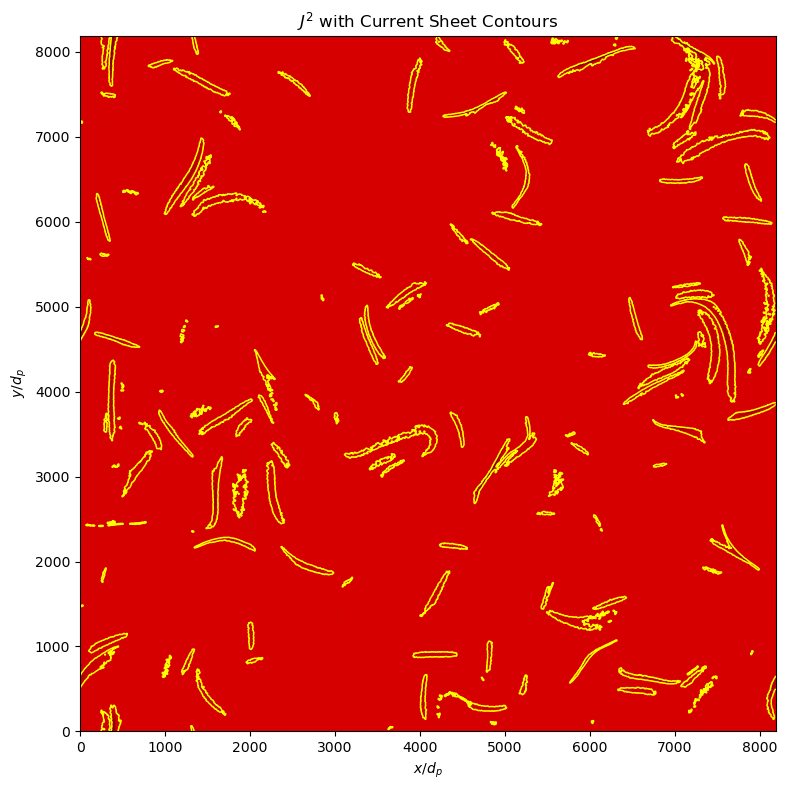

In [8]:
#Plot current sheets over the base J_squared field

plt.figure(figsize=(10, 8))

# Base field
plt.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=0.05)

# Add current-sheet boundaries
plt.contour(cleaned_mask.T, levels=[0.5], colors='yellow', linewidths=1)

plt.title(r'$J^{2}$ with Current Sheet Contours')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')
plt.tight_layout()
plt.savefig("J2_HR_with_CS_contours.png", dpi=300)
plt.show()

In [7]:
#FIND MAXIMUM IN EACH CONNECTED REGION

labeled_mask, num_features = label(cleaned_mask)
print("Regions found:", num_features)

max_coords = []
max_values = []

for i in range(1, num_features + 1):
    region_mask = (labeled_mask == i)
    region_vals = J_squared[region_mask]

    if region_vals.size == 0:
        continue

    # Extreme value (max magnitude)
    max_pos = np.argmax(np.abs(region_vals))
    extreme_value = region_vals[max_pos]
    max_values.append(extreme_value)

    # Convert index → coordinates
    xs, ys = np.where(region_mask)
    max_coords.append((xs[max_pos], ys[max_pos]))

Regions found: 86


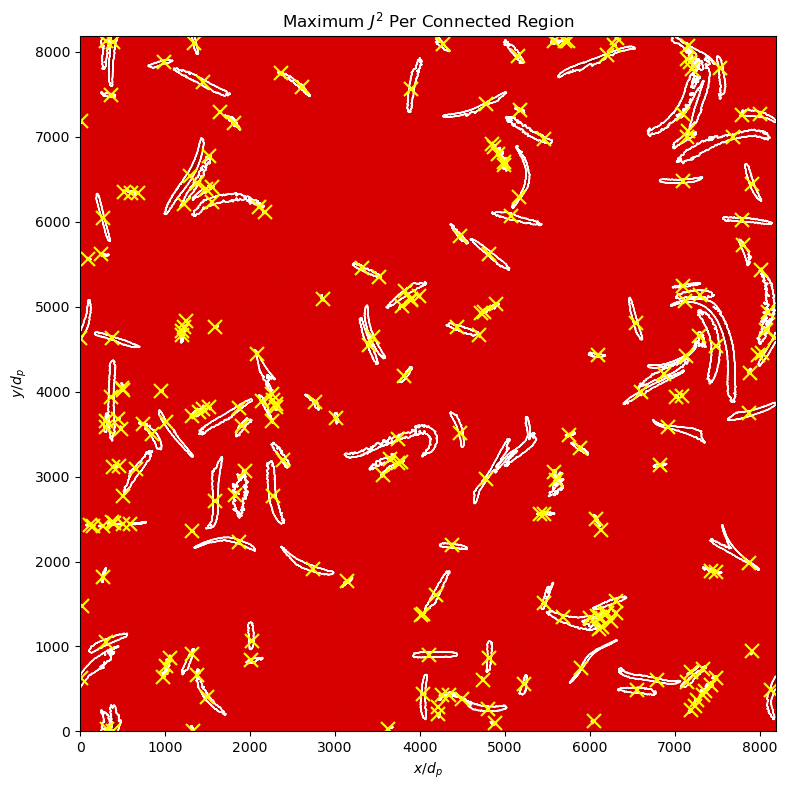

In [10]:
# PLOT ORIGINAL FIELD + MASK + MAXIMUM POINTS

plt.figure(figsize=(10, 8))

# --- Base field ---
plt.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=0.05)

# --- Boundaries of CSs---
boundaries = find_boundaries(labeled_mask)
plt.contour(boundaries.T, levels=[0.5], colors='white', linewidths=1)

# --- Overlay maxima as yellow crosses ---
for x, y in max_coords:
    plt.plot(x, y, marker='x', markersize=10, markeredgewidth=1.5, color='yellow')

plt.title(r'Maximum $J^{2}$ Per Connected Region')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')

plt.tight_layout()
plt.savefig("J2_HR_maxima_overlay.png", dpi=300)
plt.show()

In [ ]:
# Method 1 for Thickness Computation: Using the internal function for diameter of largest inscribed circle

#1. Labelling each connected region

labeled_mask = measure.label(cleaned_mask, connectivity=2)
num_regions = labeled_mask.max()
print("Number of connected regions:", num_regions)

#2. Compute thicknesses

thicknesses_m1 = []

for label_id in range(1, num_regions + 1):

    region = (labeled_mask == label_id)

    # Euclidean distance transform INSIDE the region
    dist = ndi.distance_transform_edt(region)

    # Full sheet thickness = diameter of largest inscribed circle
    thickness = 2 * dist.max()

    thicknesses_m1.append(thickness)

# 3. Some Central Measures of the statistics

print(f"Found {len(thicknesses_m1)} sheets")
print(f"Mean thickness = {np.mean(thicknesses_m1):.3f} pixels")
print(f"Median thickness = {np.median(thicknesses_m1):.3f} pixels")
print(f"Min thickness = {np.min(thicknesses_m1):.3f} px, Max = {np.max(thicknesses_m1):.3f} px")

# 4. Histogram of thicknesses

plt.figure(figsize=(7,5))
plt.hist(thicknesses_m1, bins=20)
plt.xlabel("Thickness (pixels)")
plt.ylabel("Count")
plt.title("Histogram of Sheet Thicknesses")
plt.tight_layout()
plt.savefig("J2_HR_M1_Histogram.png", dpi=300)
plt.show()    

Number of connected regions: 230


In [ ]:
#Plot a smooth PDF of the same data
plt.figure(figsize=(7,5))

# Histogram (normalized)
plt.hist(thicknesses_m1, bins=20, density=True, alpha=0.4, label="Histogram")

# KDE curve
kde = gaussian_kde(thicknesses_m1)
xs = np.linspace(min(thicknesses_m1), max(thicknesses_m1), 500)
plt.plot(xs, kde(xs), linewidth=2, label="PDF (KDE)")
plt.xlabel("Thickness (pixels)")
plt.ylabel("Probability Density")
plt.title("PDF of Sheet Thicknesses")
plt.legend()
plt.tight_layout()
plt.savefig("J2_HR_M1_PDF.png", dpi=300)
plt.show()

In [ ]:
# Compute gradient of J_squared
dJdx, dJdy = np.gradient(J_squared)  # assumes unit grid spacing

descent_dirs = []  # (dx, dy) unit vectors

for (x, y) in max_coords:
    gx = dJdx[x, y]
    gy = dJdy[x, y]

    grad = np.array([gx, gy])

    # Avoid division by zero
    if np.allclose(grad, 0):
        descent_dirs.append(np.array([0.0, 0.0]))
        continue

    # Direction of steepest descent = negative normalized gradient
    descent = -grad / np.linalg.norm(grad)
    descent_dirs.append(descent)

In [ ]:
# Plotting the steepest descent direction
fig, ax = plt.subplots(figsize=(10, 8))

# --- Base field image ---
ax.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=0.05, aspect='equal', zorder=0)

# --- Boundaries of connected structures ---
boundaries = find_boundaries(labeled_mask)
ax.contour(boundaries.T, levels=[0.5], colors='white', linewidths=1, zorder=2)

# --- Arrows for maxima (always on top) ---
factor = 100.0
for (x, y), (dx, dy) in zip(max_coords, descent_dirs):

    start = (x - 0.5 * factor * dx, y - 0.5 * factor * dy)
    end   = (x + 0.5 * factor * dx, y + 0.5 * factor * dy)

    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="<->",
        color="red",
        mutation_scale=10,
        linewidth=2,
        zorder=10             
    )
    ax.add_patch(arrow)

# --- Axis labels & title ---
ax.set_title(r'')
ax.set_xlabel(r'$x/d_p$')
ax.set_ylabel(r'$y/d_p$')

# --- Save clean figure ---
plt.tight_layout()
plt.savefig("J2_HR_Descent_Direction.png", dpi=300)
plt.show()

In [ ]:
# Method 2: End of region in the direction of steepest descent

distances = []

for (x, y), (dx, dy) in zip(max_coords, descent_dirs):
    x, y = float(x), float(y)  # ensure float for stepping
    step_size = 1  # pixel step
    max_steps = 1000  # prevent infinite loop
    
    # Step forward
    xf, yf = x, y
    steps = 0
    while steps < max_steps:
        xf_new = xf + dx*step_size
        yf_new = yf + dy*step_size
        xi, yi = int(round(xf_new)), int(round(yf_new))
        if xi < 0 or yi < 0 or xi >= cleaned_mask.shape[0] or yi >= cleaned_mask.shape[1]:
            break
        if not cleaned_mask[xi, yi]:  # left the connected region
            break
        xf, yf = xf_new, yf_new
        steps += 1
    dist_forward = np.hypot(xf - x, yf - y)

    # Step backward
    xb, yb = x, y
    steps = 0
    while steps < max_steps:
        xb_new = xb - dx*step_size
        yb_new = yb - dy*step_size
        xi, yi = int(round(xb_new)), int(round(yb_new))
        if xi < 0 or yi < 0 or xi >= cleaned_mask.shape[0] or yi >= cleaned_mask.shape[1]:
            break
        if not cleaned_mask[xi, yi]:  # left the connected region
            break
        xb, yb = xb_new, yb_new
        steps += 1
    dist_backward = np.hypot(xb - x, yb - y)

    distances.append((dist_backward, dist_forward))

In [ ]:
# Calculate total distance for each maximum = thickness
thicknesses_m2 = np.array([d[0] + d[1] for d in distances])

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(thicknesses_m2, bins=20, color='salmon', edgecolor='black', alpha=0.8)
plt.xlabel('Total distance along descent direction (pixels)')
plt.ylabel('Number of maxima')
plt.title('Histogram of total distances from maxima to region boundaries')
plt.tight_layout()
plt.savefig("J2_HR_M2_Histogram.png", dpi=300)
plt.show()

In [ ]:
#Plot a smooth PDF of the same data
plt.figure(figsize=(7,5))

# Histogram (normalized)
plt.hist(thicknesses_m2, bins=20, density=True, alpha=0.4, label="Histogram")

# KDE curve
kde = gaussian_kde(thicknesses_m2)
xs = np.linspace(min(thicknesses_m2), max(thicknesses_m2), 500)
plt.plot(xs, kde(xs), linewidth=2, label="PDF (KDE)")
plt.xlabel("Thickness (pixels)")
plt.ylabel("Probability Density")
plt.title("PDF of Sheet Thicknesses")
plt.legend()
plt.tight_layout()
plt.savefig("J2_HR_M2_PDF.png", dpi=300)
plt.show()

In [ ]:
# Method 3: Thickness = FWHMs

# ---------- Gaussian model ----------
def gaussian(t, A, mu, sigma, B):
    return A * np.exp(-(t - mu)**2 / (2*sigma**2)) + B

# ---------- Parameters ----------
max_len = 60  # half-length of profile
step_px = 1   # pixel step along line

# ---------- Storage ----------
fwhms = []
xs_list = []
vals_list = []
popts_list = []

# ---------- Main loop ----------
for (x, y), (dx, dy) in zip(max_coords, descent_dirs):

    # Skip zero vector directions
    if dx == 0 and dy == 0:
        fwhms.append(np.nan)
        xs_list.append(np.array([]))
        vals_list.append(np.array([]))
        popts_list.append([np.nan, np.nan, np.nan, np.nan])
        continue

    xs = []
    vals = []

    # Sample integer pixels along the line
    for k in range(-max_len, max_len + 1):
        xc = x + k * dx
        yc = y + k * dy
        xi = int(round(xc))
        yi = int(round(yc))

        if 0 <= xi < J_squared.shape[0] and 0 <= yi < J_squared.shape[1]:
            xs.append(k)
            vals.append(J_squared[xi, yi])
        else:
            continue  # skip out-of-bounds points

    xs = np.array(xs)
    vals = np.array(vals)

    xs_list.append(xs)
    vals_list.append(vals)

    # Handle empty or too-short profiles
    if len(vals) < 3:
        fwhms.append(np.nan)
        popts_list.append([np.nan, np.nan, np.nan, np.nan])
        continue

    # Initial Gaussian guess
    A0 = vals.max() - vals.min()
    mu0 = xs[np.argmax(vals)]
    sigma0 = max_len / 4
    B0 = vals.min()

    try:
        popt, pcov = curve_fit(gaussian, xs, vals, p0=[A0, mu0, sigma0, B0])
        A, mu, sigma, B = popt
        fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma

        fwhms.append(fwhm)
        popts_list.append(popt)
    except RuntimeError:
        fwhms.append(np.nan)
        popts_list.append([np.nan, np.nan, np.nan, np.nan])

In [ ]:
# Save all the fits to a folder
save_folder = "gaussian_fits_J2_HR"
os.makedirs(save_folder, exist_ok=True)

# ---------- Plot and save all fits ----------
for i, (xs, vals, popt, fwhm) in enumerate(zip(xs_list, vals_list, popts_list, fwhms)):

    if len(xs) == 0 or np.isnan(popt[0]):
        continue  # skip empty profiles or failed fits

    A, mu, sigma, B = popt
    x_dense = np.linspace(xs.min(), xs.max(), 500)
    fit_curve = A * np.exp(-(x_dense - mu)**2 / (2*sigma**2)) + B

    plt.figure()
    plt.plot(xs, vals, 'o', label="sampled profile")
    plt.plot(x_dense, fit_curve, label="Gaussian fit")
    plt.title(f"Sample {i} — FWHM = {fwhm:.2f} px")
    plt.xlabel("t (pixels)")
    plt.ylabel("Intensity")
    plt.legend()

    # Save figure
    filename = os.path.join(save_folder, f"fit_{i:03d}.png")
    plt.savefig(filename)
    plt.close()

In [ ]:
# Convert to numpy array and remove NaNs
fwhms_array = np.array(fwhms)
thicknesses_m3 = fwhms_array[~np.isnan(fwhms_array)]

plt.figure(figsize=(8, 5))
plt.hist(thicknesses_m3, bins=20, color='skyblue', edgecolor='k')
plt.title("Histogram of FWHM values")
plt.xlabel("FWHM (pixels)")
plt.ylabel("Count")
plt.savefig("J2_HR_M3_Histogram.png", dpi=300)
plt.show()

In [ ]:
#Plot a smooth PDF of the same data
plt.figure(figsize=(7,5))

# Histogram (normalized)
plt.hist(thicknesses_m3, bins=20, density=True, alpha=0.4, label="Histogram")

# KDE curve
kde = gaussian_kde(thicknesses_m3)
xs = np.linspace(min(thicknesses_m3), max(thicknesses_m3), 500)
plt.plot(xs, kde(xs), linewidth=2, label="PDF (KDE)")
plt.xlabel("Thickness (pixels)")
plt.ylabel("Probability Density")
plt.title("PDF of Sheet Thicknesses")
plt.legend()
plt.tight_layout()
plt.savefig("J2_HR_M3_PDF.png", dpi=300)
plt.show()

In [ ]:
# Method 4: Finding maxima first and then find thickness(Zhdankin Algorithm)

def local_maxima_mask(field, threshold, n):
    
    # Apply threshold
    mask = field > threshold
    
    # Compute local maximum in a (2n+1)x(2n+1) neighborhood
    local_max = maximum_filter(field, size=(2*n+1), mode='wrap')
    
    # Keep only points that are equal to local maximum and above threshold
    maxima_mask = (field == local_max) & mask
    
    return maxima_mask.astype(int)

def grow_regions(J2_FT, maxima_mask, J_thresh_region):
    """Grow regions above region threshold connected to local maxima."""
    J_abs = np.abs(J2_FT)

    # Mask of all points above region threshold
    above_thresh = (J_abs > J_thresh_region).astype(int)

    # Label connected regions
    labeled_regions, num_features = label(above_thresh, structure=np.ones((3,3)))

    # Keep only those regions that contain a local maximum
    keep_labels = np.unique(labeled_regions[maxima_mask.astype(bool)])
    keep_labels = keep_labels[keep_labels > 0]  # drop background=0

    region_mask = np.isin(labeled_regions, keep_labels).astype(int)

    return region_mask, labeled_regions

J_squared_rms = np.sqrt(np.mean(J_squared**2))
n = 50   # neighborhood radius
maxima_mask = local_maxima_mask(J_squared, 3*J_squared_rms, n)

In [ ]:
# Plot J_squared with maxima overlay
plt.figure(figsize=(10, 8))
img = plt.imshow(J_squared, cmap='seismic', vmin=-1.5, vmax=1.5, origin='lower')
plt.colorbar(img, label=r'$J_\parallel$')

# Overlay local maxima
y_idx, x_idx = np.where(maxima_mask)
plt.scatter(x_idx, y_idx, marker='x', color='black', s=25, label='Local maxima')

plt.title(r'Local maxima of $J_\parallel$')
plt.xlabel(r'$x/d_{p}$')
plt.ylabel(r'$y/d_{p}$')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Calculating J_squared_rms
J_squared_rms = np.sqrt(np.mean(J_squared**2))

# Defining Thresholds
J2_thresh_peak = 3*J_squared_rms     # threshold for detecting maxima
J2_thresh_region = 0.005*np.max(J_squared)   # threshold for growing regions
n = 50                   # neighborhood radius for non-max suppression

# Step 1: detect peaks
maxima_mask = local_maxima_mask(J_squared, J2_thresh_peak, n)

# Step 2: grow regions around peaks
region_mask, labeled_regions = grow_regions(J_squared, maxima_mask, J2_thresh_region)

#MORPHOLOGICAL SMOOTHING
struct = morphology.disk(2)

smoothed_mask = morphology.binary_opening(region_mask, struct)
smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
smoothed_mask = smoothed_mask.astype(int)

# Number of Current sheets
labeled_mask, num_features = label(smoothed_mask)
print("Regions found:", num_features)

# Step 3: plot results
plt.figure(figsize=(10, 8))
img = plt.imshow(J_squared.T, cmap='seismic', vmax=0.05, origin='lower')
plt.colorbar(img, label=r'$J_\parallel$')

# Overlay region mask as small white dots
y_reg, x_reg = np.where(region_mask == 1)
plt.scatter(y_reg, x_reg, s=5, color='black', alpha=0.6, label='Regions above J_thresh_region')

# Overlay maxima as red X’s
y_peak, x_peak = np.where(maxima_mask == 1)
plt.scatter(y_peak, x_peak, marker='x', color='red', s=50, label='Local maxima')

plt.title(r'Current sheet peaks and regions')
plt.xlabel(r'$x/d_{p}$')
plt.ylabel(r'$y/d_{p}$')
plt.legend()
plt.tight_layout()
plt.savefig("J2_HR_M4_maxima_overlay.png", dpi=300)
plt.show()

In [ ]:
# Compute gradient of J_squared
dJdx, dJdy = np.gradient(J_squared)  # assumes unit grid spacing

descent_dirs = []  # (dx, dy) unit vectors

y_peak, x_peak = np.where(maxima_mask == 1)
max_coords = list(zip(y_peak, x_peak))

for (x, y) in max_coords:
    gx = dJdx[x, y]
    gy = dJdy[x, y]

    grad = np.array([gx, gy])

    # Avoid division by zero
    if np.allclose(grad, 0):
        descent_dirs.append(np.array([0.0, 0.0]))
        continue

    # Direction of steepest descent = negative normalized gradient
    descent = -grad / np.linalg.norm(grad)
    descent_dirs.append(descent)

In [ ]:
# Plotting the steepest descent direction
fig, ax = plt.subplots(figsize=(10, 8))

# --- Base field image ---
ax.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=0.05, aspect='equal', zorder=0)

# --- Boundaries of connected structures ---
boundaries = find_boundaries(labeled_mask)
ax.contour(boundaries.T, levels=[0.5], colors='white', linewidths=1, zorder=2)

# --- Arrows for maxima (always on top) ---
factor = 100.0
for (x, y), (dx, dy) in zip(max_coords, descent_dirs):

    start = (x - 0.5 * factor * dx, y - 0.5 * factor * dy)
    end   = (x + 0.5 * factor * dx, y + 0.5 * factor * dy)

    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="<->",
        color="red",
        mutation_scale=10,
        linewidth=2,
        zorder=10             
    )
    ax.add_patch(arrow)

# --- Axis labels & title ---
ax.set_title(r'')
ax.set_xlabel(r'$x/d_p$')
ax.set_ylabel(r'$y/d_p$')

# --- Save clean figure ---
plt.tight_layout()
plt.savefig("J2_HR_M4_Descent_Direction.png", dpi=300)

plt.show()

In [ ]:
distances = []

for (x, y), (dx, dy) in zip(max_coords, descent_dirs):
    x, y = float(x), float(y)  # ensure float for stepping
    step_size = 1  # pixel step
    max_steps = 1000  # prevent infinite loop
    
    # Step forward
    xf, yf = x, y
    steps = 0
    while steps < max_steps:
        xf_new = xf + dx*step_size
        yf_new = yf + dy*step_size
        xi, yi = int(round(xf_new)), int(round(yf_new))
        if xi < 0 or yi < 0 or xi >= smoothed_mask.shape[0] or yi >= smoothed_mask.shape[1]:
            break
        if not smoothed_mask[xi, yi]:  # left the connected region
            break
        xf, yf = xf_new, yf_new
        steps += 1
    dist_forward = np.hypot(xf - x, yf - y)

    # Step backward
    xb, yb = x, y
    steps = 0
    while steps < max_steps:
        xb_new = xb - dx*step_size
        yb_new = yb - dy*step_size
        xi, yi = int(round(xb_new)), int(round(yb_new))
        if xi < 0 or yi < 0 or xi >= smoothed_mask.shape[0] or yi >= smoothed_mask.shape[1]:
            break
        if not smoothed_mask[xi, yi]:  # left the connected region
            break
        xb, yb = xb_new, yb_new
        steps += 1
    dist_backward = np.hypot(xb - x, yb - y)

    distances.append((dist_backward, dist_forward))

In [ ]:
# Calculate total distance for each maximum = thickness
thicknesses_m4 = np.array([d[0] + d[1] for d in distances])

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(thicknesses_m4, bins=20, color='salmon', edgecolor='black', alpha=0.8)
plt.xlabel('Total distance along descent direction (pixels)')
plt.ylabel('Number of maxima')
plt.title('Histogram of total distances from maxima to region boundaries')
plt.tight_layout()
plt.savefig("J2_HR_M4_Histogram.png", dpi=300)
plt.show()

In [ ]:
#Plot a smooth PDF of the same data
plt.figure(figsize=(7,5))

# Histogram (normalized)
plt.hist(thicknesses_m4, bins=20, density=True, alpha=0.4, label="Histogram")

# KDE curve
kde = gaussian_kde(thicknesses_m4)
xs = np.linspace(min(thicknesses_m4), max(thicknesses_m4), 500)
plt.plot(xs, kde(xs), linewidth=2, label="PDF (KDE)")
plt.xlabel("Thickness (pixels)")
plt.ylabel("Probability Density")
plt.title("PDF of Sheet Thicknesses")
plt.legend()
plt.tight_layout()
plt.savefig("J2_HR_M4_PDF.png", dpi=300)
plt.show()

In [ ]:
# --- Filter values between 0 and 100 (inclusive) ---
def filter_vals(arr, min_val=0, max_val=100):
    arr = np.array(arr)
    return arr[(arr >= min_val) & (arr <= max_val)]

# --- Filter each method's thickness values ---
t1 = filter_vals(thicknesses_m1, 0, 100)
t2 = filter_vals(thicknesses_m2, 0, 100)
t3 = filter_vals(thicknesses_m3, 0, 100)
t4 = filter_vals(thicknesses_m4, 0, 100)

# --- Plot settings ---
plt.figure(figsize=(8, 6))
bins = 50
hist_range = (0, 100)

# --- Plot histograms ---
plt.hist(t1, bins=bins, range=hist_range, alpha=0.6,
         label='Thicknesses Method 1',
         color='darkorange', edgecolor='black', density=True)

plt.hist(t2, bins=bins, range=hist_range, alpha=0.6,
         label='Thicknesses Method 2',
         color='dodgerblue', edgecolor='black', density=True)

plt.hist(t3, bins=bins, range=hist_range, alpha=0.6,
         label='Thicknesses Method 3',
         color='seagreen', edgecolor='black', density=True)

plt.hist(t4, bins=bins, range=hist_range, alpha=0.6,
         label='Thicknesses Method 4',
         color='mediumorchid', edgecolor='black', density=True)

# --- Labels and title ---
plt.xlabel('Value (pixels)')
plt.ylabel('Probability density')
plt.title('Comparison of Thicknesses (0 ≤ values ≤ 100)')
plt.legend()

# --- Save and show ---
plt.tight_layout()
plt.savefig("J2_HR_Histogram.png", dpi=300)
plt.show()

In [ ]:
# --- Filter values between 0 and 100 (inclusive) ---
def filter_vals(arr, min_val=0, max_val=100):
    arr = np.array(arr)
    return arr[(arr >= min_val) & (arr <= max_val)]

# --- Filter data ---
t1 = filter_vals(thicknesses_m1, 0, 100)
t2 = filter_vals(thicknesses_m2, 0, 100)
t3 = filter_vals(thicknesses_m3, 0, 100)
t4 = filter_vals(thicknesses_m4, 0, 100)

# --- Plot ---
plt.figure(figsize=(8, 6))

sns.kdeplot(t1, color='darkorange', label='Method 1 KDE', linewidth=2, clip=(0, 100))
sns.kdeplot(t2, color='dodgerblue', label='Method 2 KDE', linewidth=2, clip=(0, 100))
sns.kdeplot(t3, color='seagreen', label='Method 3 KDE', linewidth=2, clip=(0, 100))
sns.kdeplot(t4, color='mediumorchid', label='Method 4 KDE', linewidth=2, clip=(0, 100))

# --- Labels and title ---
plt.xlabel('Value (pixels)')
plt.ylabel('Probability density')
plt.title('Comparison of Thicknesses with KDE (0 ≤ values ≤ 100)')
plt.legend()

# --- Save and show ---
plt.tight_layout()
plt.savefig("J2_HR_PDF.png", dpi=300)
plt.show()